# Importing python libraries

In [82]:
import os
import numpy as np
import librosa
from tqdm import tqdm
import ordpy
from sklearn.preprocessing import StandardScaler
import itertools
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import IPython.display as ipd
from scipy.signal import correlate
from scipy.stats import mannwhitneyu

In [2]:
HUMAN_DIR = 'data/human/wav/classical'
AI_DIR = 'data/ai/wav/classical'

In [ ]:
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

# Downloading data

In [ ]:
def load_audio_files(human_dir, ai_dir, sr=16000, duration=None):
    signals = []
    labels = []
    
    human_files = [f for f in sorted(os.listdir(human_dir)) if f.endswith(".wav")]
    ai_files = [f for f in sorted(os.listdir(ai_dir)) if f.endswith(".wav")]
    
    for filepath in tqdm(human_files, desc="Loading human music"):
        full_path = os.path.join(human_dir, filepath)
        y, _ = librosa.load(full_path, sr=sr, duration=duration, mono=True)
        signals.append(y)
        labels.append(0)
    
    for filepath in tqdm(ai_files, desc="Loading AI music"):
        full_path = os.path.join(ai_dir, filepath)
        y, _ = librosa.load(full_path, sr=sr, duration=duration, mono=True)
        signals.append(y)
        labels.append(1)
    
    print(f"Downloaded: {labels.count(0)} human, {labels.count(1)} AI tracks")
    return signals, labels

## sr = 16000

In [66]:
standard_signals, standard_labels = load_audio_files(HUMAN_DIR, AI_DIR, sr=4400)

Loading AI music: 100%|██████████| 50/50 [00:00<00:00, 692.99it/s]

Downloaded: 50 human, 50 AI tracks


## sr = 4400

In [87]:
signals, labels = load_audio_files(HUMAN_DIR, AI_DIR, sr=4400)

Loading AI music: 100%|██████████| 50/50 [00:00<00:00, 720.15it/s]

Downloaded: 50 human, 50 AI tracks


# Computing complexity-entropy with ``ordpy``

In [ ]:
def compute_HC(signal, D, tau=1):
    try:
        H, C = ordpy.complexity_entropy(signal, dx=D, taux=tau)
        return H, C
    except Exception as e:
        print(f"Error when computing HC for dx={D}, taux={tau}: {e}")
        return None, None


def compute_HC_for_dataset(signals, D, tau=1):
    points = []
    valid_indices = []
    
    for i, signal in enumerate(signals):
        H, C = compute_HC(signal, D=D, tau=tau)
        if H is not None:
            points.append([H, C])
            valid_indices.append(i)
    
    return np.array(points), valid_indices

# Implementing Grid Search

In [ ]:
def grid_search_HC(signals, labels, dx_values=[3, 4, 5, 6, 7, 8, 9, 10], taux_values=[5, 10, 15, 20, 25]):
    results = []
    ordpy_combos = list(itertools.product(dx_values, taux_values))
    
    for dx, taux in tqdm(ordpy_combos, desc="ordpy params"):
        points, valid_idx = compute_HC_for_dataset(signals, D=dx, tau=taux)
        valid_labels = np.array([labels[i] for i in valid_idx])
        try:
            sil = silhouette_score(points, valid_labels)
        except:
            sil = -1
        
        try:
            lda = LinearDiscriminantAnalysis()
            lda.fit(points, valid_labels)
            lda_score = lda.score(points, valid_labels)
        except:
            lda_score = 0
        
        results.append({"dx": dx, "taux": taux, "silhouette": sil, "lda_score": lda_score, "n_valid_points": len(points)})
    
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values("silhouette", ascending=False).reset_index(drop=True)
    
    return results_df

## sr = 16000

In [67]:
results_df = grid_search_HC(standard_signals, standard_labels)

ordpy params: 100%|██████████| 40/40 [10:34<00:00, 15.85s/it]


In [68]:
results_df.to_csv("grid_search_results_classical2.csv", index=False)

In [69]:
results_df.head(20)

,dx,taux,silhouette,lda_score,n_valid_points
0,10,25,0.861259,0.99,100
1,10,20,0.858814,0.99,100
2,10,15,0.842265,0.99,100
3,9,20,0.833440,0.99,100
4,9,25,0.831321,0.99,100
5,9,15,0.830854,0.99,100
6,10,10,0.827915,0.99,100
7,10,5,0.817216,0.99,100
8,9,10,0.807912,0.99,100
9,9,5,0.795082,0.99,100


## sr = 4400

In [13]:
results_df = grid_search_HC(signals, labels)

ordpy params: 100%|██████████| 40/40 [10:43<00:00, 16.09s/it]


In [14]:
results_df.to_csv("grid_search_results_classical.csv", index=False)

In [15]:
results_df.head(20)

,dx,taux,silhouette,lda_score,n_valid_points
0,10,25,0.861259,0.99,100
1,10,20,0.858814,0.99,100
2,10,15,0.842265,0.99,100
3,9,20,0.833440,0.99,100
4,9,25,0.831321,0.99,100
5,9,15,0.830854,0.99,100
6,10,10,0.827915,0.99,100
7,10,5,0.817216,0.99,100
8,9,10,0.807912,0.99,100
9,9,5,0.795082,0.99,100


> D = 10, tau = 25

In [19]:
D = 10
tau = 25

In [20]:
points, valid_idx = compute_HC_for_dataset(signals, D=D, tau=tau)
valid_labels = [labels[i] for i in valid_idx]

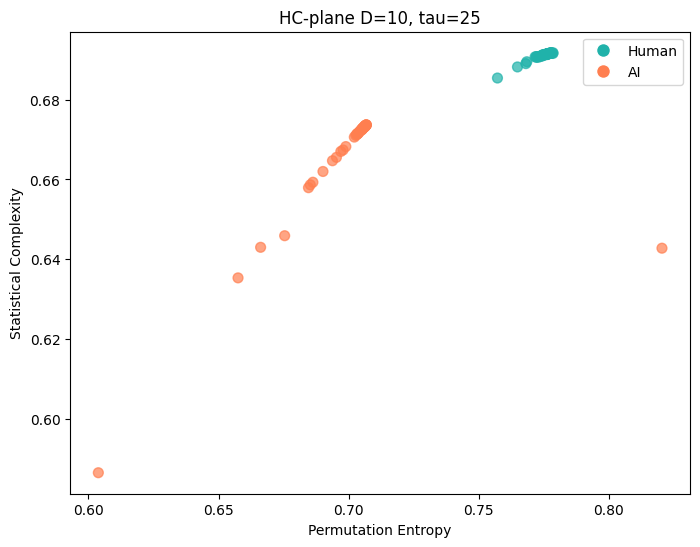

In [21]:
colors = ["lightseagreen" if l == 0 else "coral" for l in valid_labels]

plt.figure(figsize=(8, 6))
plt.scatter(points[:, 0], points[:, 1], c=colors, alpha=0.7, s=50)
plt.xlabel("Permutation Entropy")
plt.ylabel("Statistical Complexity")
plt.title(f"HC-plane D={D}, tau={tau}")
plt.legend(handles=[
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='lightseagreen', markersize=10, label='Human'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='coral', markersize=10, label='AI')
])
plt.show()

In [ ]:
H_human = points[:50, 0]
C_human= points[:50, 1]
H_ai = points[50:, 0]
C_ai = points[50:, 1]

print(f"Classical: median H = {np.median(H_human):.4f}, median C = {np.median(C_human):.4f}")
print(f"AI: median H = {np.median(H_ai):.4f}, median C = {np.median(C_ai):.4f}")

stat_H, p_H = mannwhitneyu(H_human, H_ai, alternative='two-sided')
print(f"Mann-Whitney H: p = {p_H:.4f}")

stat_C, p_C = mannwhitneyu(C_human, C_ai, alternative='two-sided')
print(f"Mann-Whitney C: p = {p_C:.4f}")

Classical: median H = 0.7762, median C = 0.6914
AI: median H = 0.7051, median C = 0.6725
Mann-Whitney H: p = 0.0000
Mann-Whitney C: p = 0.0000


# Подбор гиперпараметров для вычисления фрактальной размерности

## FNN rate (подбор dimension embedding)

In [22]:
from scipy.signal import correlate
from scipy.spatial import KDTree
from collections import defaultdict

FFN rate (алгоритм):
1. реконструируем фазовое пространсво для d и d + 1
2. ищем ближайшего соседа в d-мерном пространстве
3. ищем расстояние до того же соседа [индекса] в (d + 1)-мерном пространстве
4. считаем относительное изменение расстояния
5. считает false nearest neighboor как среднее всех относительных изменений, которые выросли в 10 раз


In [ ]:
def embed(signal, d, tau):
    N = len(signal) - (d - 1) * tau
    return np.stack([signal[i * tau: i * tau + N] for i in range(d)], axis=1)

def fnn_rate(signal, d_max=10, tau=1, rtol= 15.0, sample=10_000, rng=None):
    if rng is None:
        rng = np.random.default_rng(42)

    rates = []
    for d in range(1, d_max + 1):
        Y_d, Y_d1 = embed(signal, d, tau), embed(signal, d + 1, tau)
        n = min(len(Y_d), len(Y_d1), sample)
        idx = rng.choice(min(len(Y_d), len(Y_d1)), size=n, replace=False)
        Yd = Y_d[idx]
        Yd1 = Y_d1[idx]

        tree = KDTree(Yd)
        dists, nn_idx = tree.query(Yd, k=2)
        r_d, nn = dists[:, 1], nn_idx[:, 1]
        r_d1 = np.linalg.norm(Yd1 - Yd1[nn], axis=1)

        safe = r_d > 1e-10
        ratio = np.zeros(n)
        ratio[safe] = np.abs(r_d1[safe] - r_d[safe]) / r_d[safe]

        fnn = np.mean(ratio > rtol)
        rates.append(fnn)

    return np.array(rates)

Так как считать FNN rate на всем сигнале дорого, то берем всего 10000 сэмплов. 

In [ ]:
FNN_SAMPLE = 10000
FNN_D_MAX = 10
FNN_RTOL = 10.0
FNN_TAU = 1

In [ ]:
class_rates = defaultdict(list)
class_dopt = defaultdict(list)

for sig, lbl in tqdm(zip(signals, labels),total=len(signals), desc='FNN'):
    sig = np.array(sig, dtype=np.float64)
    if len(sig) > FNN_SAMPLE:
        start = rng.integers(0, len(sig) - FNN_SAMPLE)
        sig_sub = sig[start: start + FNN_SAMPLE]
    else:
        sig_sub = sig

    rates = fnn_rate(sig_sub, d_max=FNN_D_MAX, tau=FNN_TAU, rtol=FNN_RTOL, rng=rng)

    below = np.where(rates < 0.01)[0]
    D_opt = int(below[0]) + 1 if len(below) > 0 else FNN_D_MAX

    class_rates[lbl].append(rates)
    class_dopt[lbl].append(D_opt)

FNN: 100%|██████████| 100/100 [00:33<00:00,  3.00it/s]


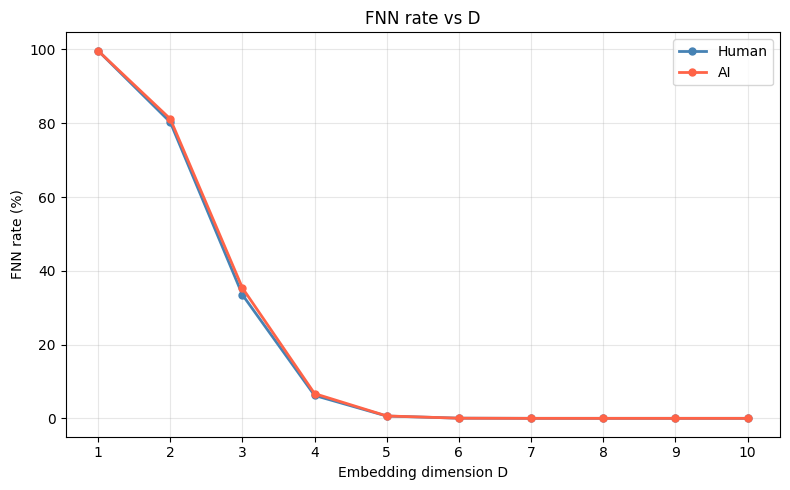

In [ ]:
colors  = {lbl: c for lbl, c in zip(sorted(class_rates.keys()), ['steelblue', 'tomato'])}
d_range = np.arange(1, FNN_D_MAX + 1)

fig, ax = plt.subplots(figsize=(8, 5))
for lbl, rate_list in sorted(class_rates.items()):
    mat = np.array(rate_list) * 100
    med = np.median(mat, axis=0)
    c = colors[lbl]
    ax.plot(d_range, med, marker='o', ms=5, lw=2, color=c, label=f'{'Human' if lbl == 0 else 'AI'}')
ax.set_xlabel('Embedding dimension D')
ax.set_ylabel('FNN rate (%)')
ax.set_title(f'FNN rate vs D')
ax.set_xticks(d_range)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

> $D^* = 5$ для обоих классов

## ACF для tau

In [32]:
MAX_TAU = 15

In [28]:
def compute_acf(signal, tau_max):
    x = signal - signal.mean()
    full = correlate(x, x, mode='full')
    mid  = len(full) // 2
    acf  = full[mid:mid + tau_max + 1]
    acf /= acf[0]
    return acf

def first_zero_crossing(acf):
    for i in range(1, len(acf)):
        if acf[i] <= 0.0:
            t = i - 1 + acf[i-1] / (acf[i-1] - acf[i])
            return int(round(t))
    return len(acf) - 1

In [ ]:
class_acf  = defaultdict(list)
class_taus = defaultdict(list)

for sig, lbl in tqdm(zip(signals, labels), total=len(signals), desc='ACF'):
    sig = np.array(sig, dtype=np.float64)
    acf = compute_acf(sig, MAX_TAU)
    tau = first_zero_crossing(acf)
    class_acf[lbl].append(acf)
    class_taus[lbl].append(tau)

ACF: 100%|██████████| 100/100 [00:00<00:00, 293.45it/s]


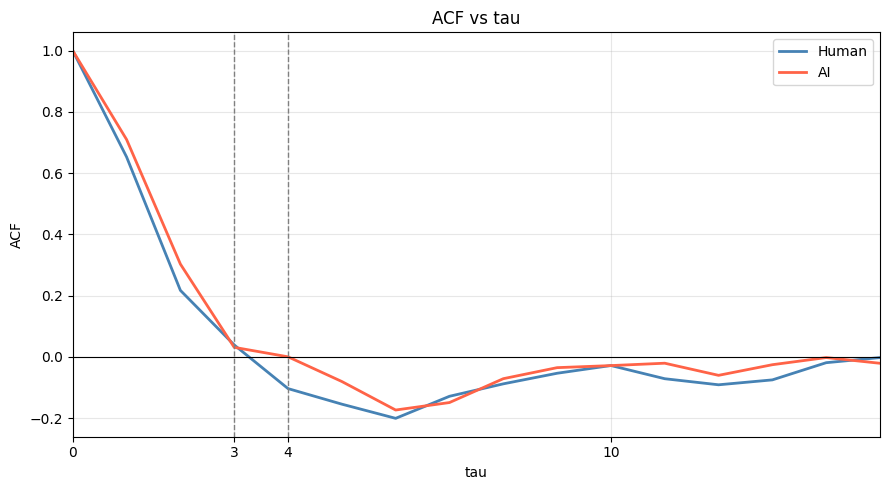

In [ ]:
colors  = {lbl: c for lbl, c in zip(sorted(class_acf.keys()), ['steelblue', 'tomato'])}
lags = np.arange(0, MAX_TAU + 1)

fig, ax = plt.subplots(figsize=(9, 5))
for lbl, acf_list in sorted(class_acf.items()):
    mat = np.array(acf_list)
    med = np.median(mat, axis=0)
    tau_med = int(np.median(class_taus[lbl]))
    c = colors[lbl]
    ax.plot(lags, med, lw=2, color=c, label=f'{'Human' if lbl == 0 else 'AI'}')
ax.axvline(4, color='gray', ls='--', lw=1)
ax.axvline(3, color='gray', ls='--', lw=1)
ax.axhline(0,  color='black',  lw=0.8)
ax.set_xlabel('tau')
ax.set_ylabel('ACF')
ax.set_title(f'ACF vs tau')
ax.set_xlim(0, 15)
ax.legend()
ax.grid(alpha=0.3)
ax.set_xticks(list(range(0, MAX_TAU + 1, 10))+ [4, 3])
plt.tight_layout()
plt.show()

## MI для tau

In [39]:
N_BINS  = 64
TAU_MAX = 15

In [ ]:
def compute_mi_curve(signal, tau_max, n_bins):
    vmin, vmax = signal.min(), signal.max()
    edges = np.linspace(vmin, vmax, n_bins + 1)
    mi_vals = []
    for tau in range(1, tau_max + 1):
        x = signal[:-tau]
        y = signal[tau:]
        joint, _, _ = np.histogram2d(x, y, bins=[edges, edges])
        joint = joint / joint.sum()

        px = joint.sum(axis=1)
        py = joint.sum(axis=0)
        denom = np.outer(px, py)
        denom[denom == 0] = 1e-12

        mask = joint > 0
        mi = (joint[mask] * np.log2(joint[mask] / denom[mask])).sum()
        mi_vals.append(max(mi, 0.0))

    return np.array(mi_vals)


def first_local_min(curve: np.ndarray) -> int:
    for i in range(1, len(curve) - 1):
        if curve[i] < curve[i-1] and curve[i] < curve[i+1]:
            return i + 1
    return int(np.argmin(curve)) + 1

In [ ]:
class_mi = defaultdict(list)
class_taus_mi = defaultdict(list)

for sig, lbl in tqdm(zip(signals, labels), total=len(signals), desc='MI'):
    sig = np.array(sig, dtype=np.float64)
    mi_cur = compute_mi_curve(sig, TAU_MAX, N_BINS)
    tau_mi = first_local_min(mi_cur)
    class_mi[lbl].append(mi_cur)
    class_taus_mi[lbl].append(tau_mi)

MI: 100%|██████████| 100/100 [00:05<00:00, 18.73it/s]


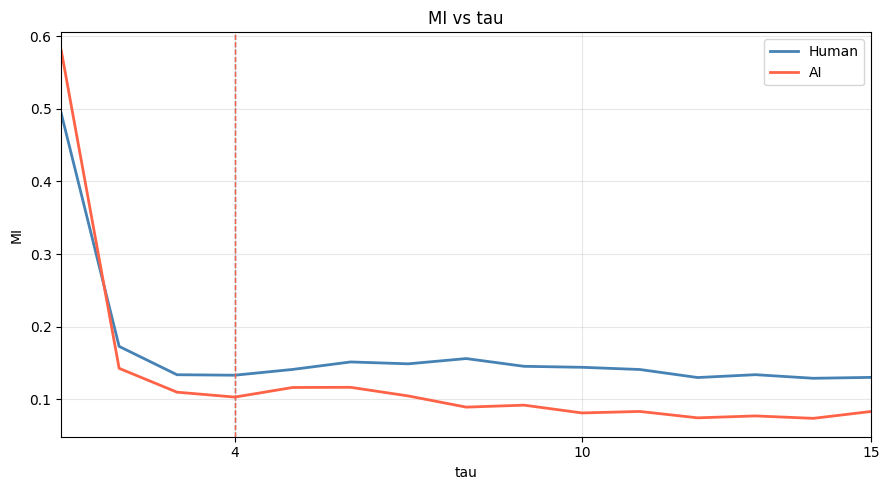

In [ ]:
colors  = {lbl: c for lbl, c in zip(sorted(class_mi.keys()), ['steelblue', 'tomato'])}
mi_lags = np.arange(1, TAU_MAX + 1)

fig, ax = plt.subplots(figsize=(9, 5))
for lbl, mi_list in sorted(class_mi.items()):
    mat = np.array(mi_list)
    med = np.median(mat, axis=0)
    tau_med_curve = first_local_min(med)
    c = colors[lbl]
    ax.plot(mi_lags, med, lw=2, color=c, label=f'{'Human' if lbl == 0 else 'AI'}')
    ax.axvline(tau_med_curve, color=c, ls='--', lw=1)
ax.set_xlabel('tau')
ax.set_ylabel('MI')
ax.set_title(f'MI vs tau')
ax.set_xlim(1, 15)
ax.legend()
ax.grid(alpha=0.3)
ax.set_xticks([4, 10, 15])
plt.tight_layout()
plt.show()

## H-C plane with D=5, tau=4

In [46]:
lower_points, lower_valid_idx = compute_HC_for_dataset(signals, D=5, tau=4)
lower_valid_labels = [labels[i] for i in lower_valid_idx]

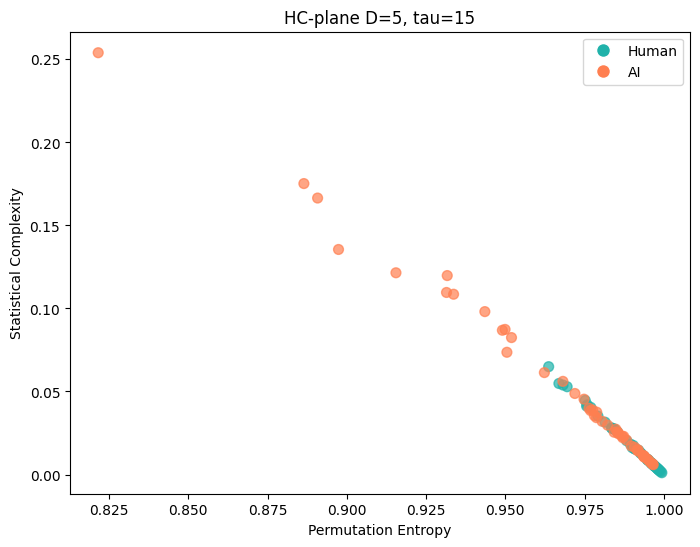

In [47]:
colors = ["lightseagreen" if l == 0 else "coral" for l in lower_valid_labels]

plt.figure(figsize=(8, 6))
plt.scatter(lower_points[:, 0], lower_points[:, 1], c=colors, alpha=0.7, s=50)
plt.xlabel("Permutation Entropy")
plt.ylabel("Statistical Complexity")
plt.title(f"HC-plane D={5}, tau={15}")
plt.legend(handles=[
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='lightseagreen', markersize=10, label='Human'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='coral', markersize=10, label='AI')
])
plt.show()

# Фрактальные размерности

## Алгоритм Швайнхарта

In [48]:
from scipy.sparse.csgraph import minimum_spanning_tree
from scipy.spatial.distance import cdist
from scipy.optimize import curve_fit
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

1. Реконструкция фазового пространства с параметрами

> $D = 5, \tau = 4$

In [49]:
def reconstruct_signal(signal, tau, D):
    length = len(signal)
    rec_signal_length = length - (D - 1) * tau
    return np.array([signal[i:i + D * tau:tau] for i in range(rec_signal_length)])

In [ ]:
D, TAU = 5, 4

reconstructed_signals = []
for signal in signals:
    emb = reconstruct_signal(signal, TAU, D)
    reconstructed_signals.append(emb)

In [51]:
reconstructed_signals[0].shape

(132043, 5)

2. Сэмплирование $K$ подмножеств разных размеров, для каждого подмножества строим минимальное остовное дерево, считаем $E_{\alpha}^0$

In [52]:
def mst_edge_weights(points):
    dist_matrix = cdist(points, points, metric='euclidean')
    mst = minimum_spanning_tree(dist_matrix)
    return mst.data

def compute_E_alpha(edge_weights, alpha_values):
    return np.array([np.sum(edge_weights ** alpha) for alpha in alpha_values])

In [ ]:
rng = np.random.default_rng(seed=42)

alpha_values = np.arange(1.0, 8.1, 0.2)

size_grid = np.unique(np.round(np.logspace(np.log10(200), np.log10(2000), 10)).astype(int))

n_repeats = 5
size_grid

array([ 200,  258,  334,  431,  557,  719,  928, 1199, 1549, 2000])

In [54]:
E_matrices = []

for track_idx, emb in enumerate(tqdm(reconstructed_signals, desc="треки")):
    
    E_matrix = np.zeros((len(alpha_values), len(size_grid)))
    
    for j, size in enumerate(size_grid):
        
        E_per_repeat = np.zeros((n_repeats, len(alpha_values)))
        
        for r in range(n_repeats):
            idx = rng.choice(len(emb), size=size, replace=False)
            pts = emb[idx]
            edge_weights = mst_edge_weights(pts)
            E_per_repeat[r] = compute_E_alpha(edge_weights, alpha_values)
        
        E_matrix[:, j] = E_per_repeat.mean(axis=0)
    
    E_matrices.append(E_matrix)

треки: 100%|██████████| 100/100 [08:48<00:00,  5.28s/it]


3. Строим линейную регрессию для каждого $\alpha$, находим $d^*$. Строим ДИ для $\alpha$, возвращаем медиану $d_{Schw}$ по допустимым $\alpha$ для каждого D

In [ ]:
def fit_regression(size_grid, E_values, alpha):
    ln_size = np.log(size_grid.astype(float))
    ln_E = np.log(E_values)
    
    slope, intercept, r, p, se_slope = stats.linregress(ln_size, ln_E)
    beta = slope
    
    if beta <= 0 or beta >= 1:
        return dict(d_hat=np.nan, beta=beta, valid=False)
    
    d_hat = alpha / (1.0 - beta)
    
    n = len(ln_size)
    t_crit = stats.t.ppf(0.975, df=n - 2)
    ci_beta = t_crit * se_slope
    
    gamma = 0.10
    rel_ci = ci_beta / (abs(beta) + 1e-9)
    
    valid = rel_ci <= gamma
    
    return dict(d_hat=d_hat, beta=beta, rel_ci=rel_ci, valid=valid)

In [ ]:
TAU = 4
schw_medians = {}

for D in range(5, 16):
    reconstructed_signals = []
    for signal in signals:
        emb = reconstruct_signal(signal, TAU, D)
        reconstructed_signals.append(emb)
    
    E_matrices = []
    for track_idx, emb in enumerate(tqdm(reconstructed_signals, desc="треки")):
        E_matrix = np.zeros((len(alpha_values), len(size_grid)))
        for j, size in enumerate(size_grid):
            E_per_repeat = np.zeros((n_repeats, len(alpha_values)))
            for r in range(n_repeats):
                idx = rng.choice(len(emb), size=size, replace=False)
                pts = emb[idx]
                edge_weights = mst_edge_weights(pts)
                E_per_repeat[r] = compute_E_alpha(edge_weights, alpha_values)
            E_matrix[:, j] = E_per_repeat.mean(axis=0)
        E_matrices.append(E_matrix)
    results = []

    for track_idx, E_matrix in enumerate(tqdm(E_matrices, desc="треки")):
        valid_d_hats = []
        for a_idx, alpha in enumerate(alpha_values):
            E_values = E_matrix[a_idx, :]
            mask = (E_values > 0) & np.isfinite(E_values)
            if mask.sum() < 3:
                continue
            res = fit_regression(size_grid[mask], E_values[mask], alpha)
            if res['valid'] and np.isfinite(res['d_hat']) and res['d_hat'] > 0:
                valid_d_hats.append(res['d_hat'])
        if len(valid_d_hats) == 0:
            d_median = np.nan
        else:
            d_median = np.median(valid_d_hats)

        results.append(dict(track_idx=track_idx, label=labels[track_idx], n_valid_alpha=len(valid_d_hats), d_median=d_median))
    results_df = pd.DataFrame(results)
    labels_unique = results_df['label'].unique()

    group1 = results_df[results_df['label'] == labels_unique[0]]['d_median'].dropna()
    group2 = results_df[results_df['label'] == labels_unique[1]]['d_median'].dropna()

    stat, p = mannwhitneyu(group1, group2, alternative='two-sided')
    print(f"D={D}: Mann-Whitney p = {p:.4f}")
    print(results_df.groupby('label')['d_median'].median())

    schw_medians[D] = {labels_unique[0]: group1.median(), labels_unique[1]: group2.median()}

    

треки: 100%|██████████| 100/100 [00:00<00:00, 194.94it/s]


D=5: Mann-Whitney p = 0.0000
label
0    5.612718
1    5.266480
Name: d_median, dtype: float64


треки: 100%|██████████| 100/100 [00:00<00:00, 195.58it/s]


D=6: Mann-Whitney p = 0.0000
label
0    6.623272
1    6.177793
Name: d_median, dtype: float64


треки: 100%|██████████| 100/100 [00:00<00:00, 195.34it/s]


...

D=13: Mann-Whitney p = 0.0000
label
0    11.601748
1     9.866085
Name: d_median, dtype: float64


треки: 100%|██████████| 100/100 [00:00<00:00, 190.05it/s]


D=14: Mann-Whitney p = 0.0000
label
0    11.972321
1    10.296088
Name: d_median, dtype: float64


треки: 100%|██████████| 100/100 [00:00<00:00, 193.98it/s]

D=15: Mann-Whitney p = 0.0000
label
0    12.790859
1    10.752451
Name: d_median, dtype: float64


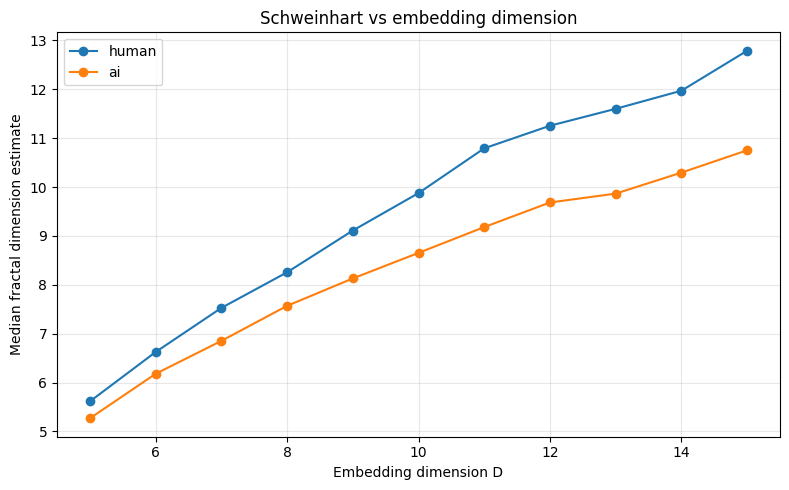

In [ ]:
D_values = list(schw_medians.keys())
label_names = list(schw_medians[D_values[0]].keys())
labels= ['human', 'ai']

fig, ax = plt.subplots(figsize=(8, 5))
for j, label in enumerate(label_names):
    medians = [schw_medians[D][label] for D in D_values]
    ax.plot(D_values, medians, marker='o', label=labels[j])
ax.set_xlabel('Embedding dimension D')
ax.set_ylabel('Median fractal dimension estimate')
ax.set_title('Schweinhart vs embedding dimension')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Алгоритм MLE

In [60]:
D, TAU = 5, 4

reconstructed_signals = []
for signal in signals:
    emb = reconstruct_signal(signal, TAU, D)
    reconstructed_signals.append(emb)

Алгоритм:

1. реконструируем фазовое пространство
2. сэмплируем N точек
3. ищем K + 1 соседей, считаем расстояние до самого дальнего соседа и расстояния до более близких соседей
4. считаем по формуле для каждой точки локальную оценку:

$$
\hat{d}_i = \left( \frac{1}{k-1} \sum_{j=1}^{k-1} \log \frac{T_k(i)}{T_j(i)} \right)^{-1}
$$



In [ ]:
def compute_mle_dim(signal, D=10, tau=20, n_samples=2000, k=10, random_seed=42):
    vectors = reconstruct_signal(signal, tau, D)

    rng = np.random.default_rng(random_seed)
    idx = rng.choice(len(vectors), size=n_samples, replace=False)
    sample = vectors[idx]

    tree = KDTree(sample)
    distances, _ = tree.query(sample, k=k + 1)
    dists = distances[:, 1:]

    T_k = dists[:, -1]
    T_j = dists[:, :-1]

    eps = 1e-10
    T_k_safe = np.maximum(T_k[:, np.newaxis], eps)
    T_j_safe = np.maximum(T_j, eps)

    log_ratios = np.log(T_k_safe / T_j_safe)
    mean_log = np.mean(log_ratios, axis=1)

    valid = mean_log > eps
    if valid.sum() == 0:
        return np.nan

    m_hat = 1.0 / mean_log[valid]

    return float(np.median(m_hat))

In [ ]:
def analyze_mle_dim(signals, labels, D=10, tau=20, n_samples=2000, k=10):
    results = []
    for i, (sig, label) in enumerate(zip(signals, labels)):
        mle = compute_mle_dim(sig, D=D, tau=tau, n_samples=n_samples, k=k)
        results.append({'track': i, 'label': label, 'mle_dim': mle})
        
    df = pd.DataFrame(results)
    print(f"Параметры: D={D}, tau={tau}, n_samples={n_samples}, k={k}")
    summary = df.groupby('label')['mle_dim'].agg(['median', 'mean', 'std'])
    print("По классам:")
    print(summary.round(3))
    return {'per_track': df, 'summary': summary}

In [63]:
results = analyze_mle_dim(signals, labels, D=D, tau=TAU)

Параметры: D=5, tau=4, n_samples=2000, k=10

По классам:
       median   mean    std
label                      
0       5.348  5.343  0.109
1       5.166  5.059  0.393


In [64]:
df = results['per_track']

In [ ]:
from scipy.stats import mannwhitneyu

human = df[df['label'] == 0]['mle_dim'].dropna()
ai = df[df['label'] == 1]['mle_dim'].dropna()

stat, p = mannwhitneyu(human, ai, alternative='two-sided')
print(f"Mann-Whitney U: stat={stat:.1f}, p={p:.4f}")


Mann-Whitney U: stat=2206.0, p=0.0000


In [ ]:
TAU = 4

mle_medians = {}
mle_results_0 = []
mle_results_1 = []

for D in range(5, 16):
    
    df = analyze_mle_dim(signals, labels, D=D, tau=TAU)['per_track']

    group0 = df[df['label'] == 0]['mle_dim'].dropna()
    group1 = df[df['label'] == 1]['mle_dim'].dropna()
    
    stat, p = mannwhitneyu(group0, group1, alternative='two-sided')
    print(f"D={D}: Mann-Whitney p = {p:.4f}")
    print(df.groupby('label')['mle_dim'].median())
    
    mle_results_0.append(group0)
    mle_results_1.append(group1)
    
    mle_medians[D] = {0: group0.median(), 1: group1.median()}

Параметры: D=5, tau=4, n_samples=2000, k=10

По классам:
       median   mean    std
label                      
0       5.348  5.343  0.109
1       5.166  5.059  0.393
D=5: Mann-Whitney p = 0.0000
label
0    5.348348
1    5.165910
Name: mle_dim, dtype: float64
Параметры: D=6, tau=4, n_samples=2000, k=10

По классам:
       median   mean    std
label                      
0       6.367  6.358  0.186
1       6.052  5.867  0.590
D=6: Mann-Whitney p = 0.0000
label
0    6.366552
1    6.051881
Name: mle_dim, dtype: float64
Параметры: D=7, tau=4, n_samples=2000, k=10

По классам:
       median   mean    std
label                      
0       7.298  7.290  0.261
1       6.818  6.587  0.801
D=7: Mann-Whitney p = 0.0000
label
0    7.297714
1    6.817685
Name: mle_dim, dtype: float64
Параметры: D=8, tau=4, n_samples=2000, k=10

По классам:
       median   mean    std
label                      
0       8.152  8.131  0.348
1       7.565  7.208  0.988
D=8: Mann-Whitney p = 0.0000
label
0    8.152

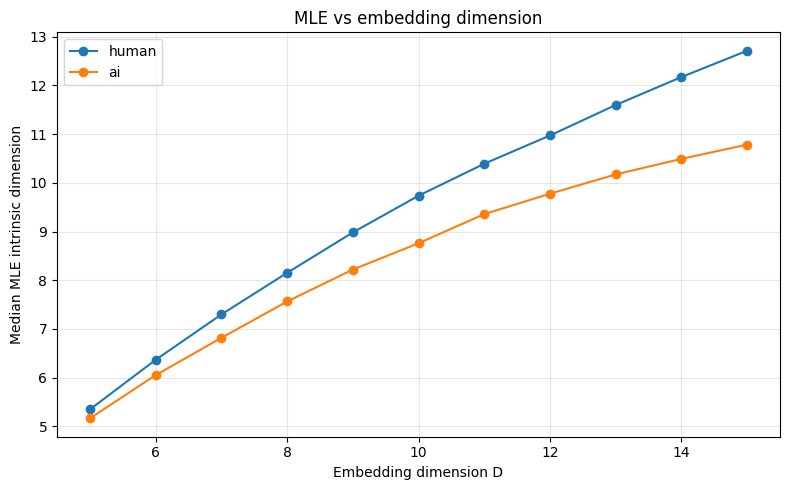

In [ ]:
D_values = list(mle_medians.keys())

fig, ax = plt.subplots(figsize=(8, 5))
for label, name in [(0, 'human'), (1, 'ai')]:
    medians = [mle_medians[D][label] for D in D_values]
    ax.plot(D_values, medians, marker='o', label=name)
ax.set_xlabel('Embedding dimension D')
ax.set_ylabel('Median MLE intrinsic dimension')
ax.set_title('MLE vs embedding dimension')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()